In [1]:
import sys,os,re
import numpy             as np
import matplotlib.pyplot as plt
import pandas            as pd
import seaborn           as sb

from source_code.mock_maker import MakeMock

from source_code.likelihood import LSSlike

from cobaya.run import run

from copy import deepcopy

import matplotlib
from matplotlib import rc
from matplotlib.pyplot import cm
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D

rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c',

yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}

In [2]:
data_path = './Validation_data/new_LSS_GW_LCDM'

In [3]:
observables =  np.load(data_path+'_source_distribution.npy',allow_pickle=True).item()
if 'GC' in observables:
    Nbins_gal = observables['GC']['Nbins']
if 'GWC' in observables:
    Nbins_gw = observables['GWC']['Nbins']

In [4]:
gal_palette = sb.blend_palette(["blue", "skyblue"], n_colors=Nbins_gal )
gw_palette = sb.blend_palette(["palevioletred", "purple"], n_colors=Nbins_gw )
cross_palette = sb.blend_palette(["darkgreen", "lightgreen"], n_colors=Nbins_gw)

Distribution plot

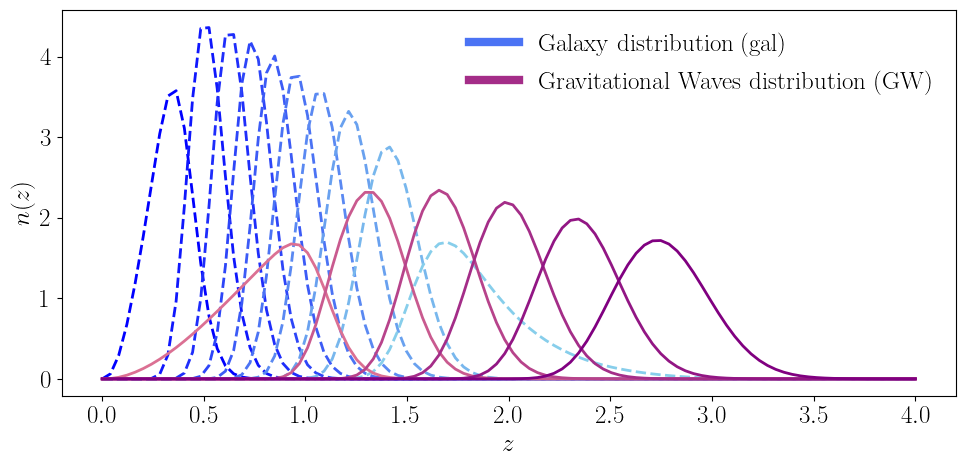

In [5]:
zplot = np.linspace(0.001, 4, 100)

plt.figure(figsize=(10, 5))
if 'GC' in observables:
    for i in range(0, Nbins_gal):
        plt.plot(zplot, observables['GC']['dist'][i](zplot), color=gal_palette[i ],linestyle='--',linewidth=2)
if 'GWC' in observables:
    for i in range(0, Nbins_gw):
        plt.plot(zplot, observables['GWC']['dist'][i](zplot), color=gw_palette[i ],linestyle='-',linewidth=2)

plt.xlabel(r'$z$', fontsize=18)
plt.ylabel(r'$n(z)$', fontsize=18)

legend_lines = [
    Line2D([0], [0], color=gal_palette[len(gal_palette)//2], lw=6, linestyle='-', label='Galaxy distribution (gal)'),
    Line2D([0], [0], color=gw_palette[len(gw_palette)//2], lw=6, linestyle='-', label='Gravitational Waves distribution (GW)'),
]
plt.legend(handles=legend_lines, loc='upper right', frameon=False, fontsize = 18)
plt.tick_params(axis='both', which='major', labelsize=18)

plt.tight_layout()
plt.savefig("./plot/n_z.png", dpi=300, bbox_inches='tight')


In [6]:
Cls = pd.read_csv(data_path+'_Cls_noiseless.dat',sep='\s+',header=0)

Cls plot

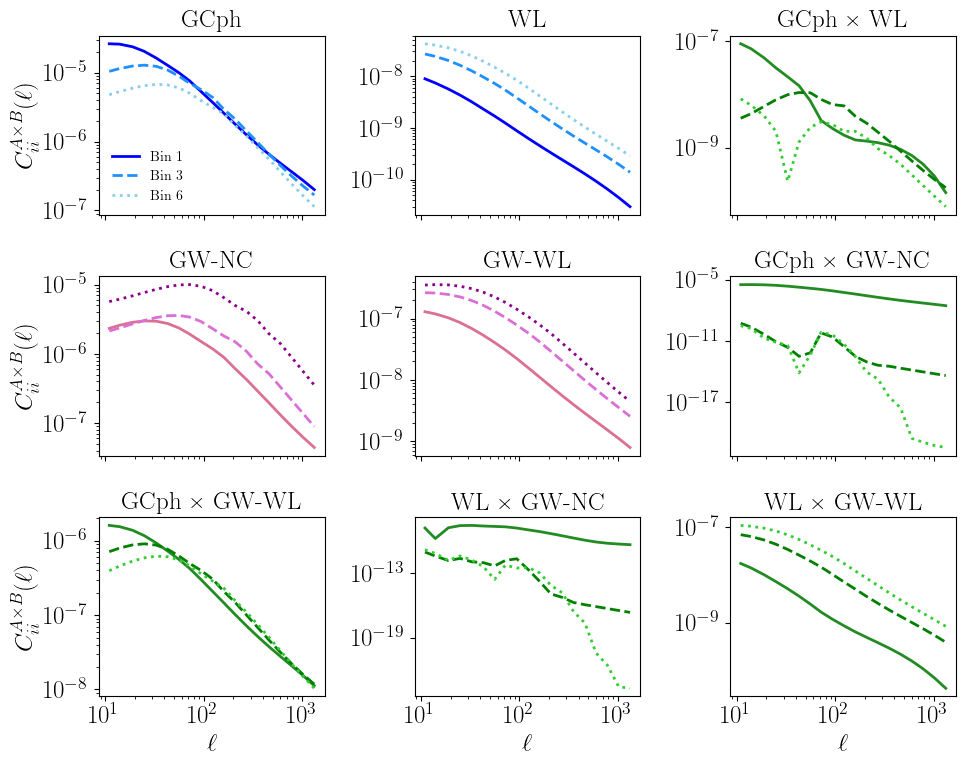

In [7]:
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches


bin_indices = [1, 3, 6]
linestyle = ['-', '--', ':']
gw_palette = ['palevioletred', 'orchid', 'darkmagenta']
cross_palette = ['forestgreen', 'green', 'limegreen']
gal_palette = ['blue', 'dodgerblue', 'skyblue']

gal_color   = 'dodgerblue'
gw_color    = 'orchid'
cross_color = 'green'

subplot_titles = [
    'GCph', 'WL', 'GCph × WL',
    'GW-NC', 'GW-WL', 'GCph × GW-NC',
    'GCph × GW-WL', 'WL × GW-NC', 'WL × GW-WL'
]

title_to_obs = [
    ('G', 'G'), ('L', 'L'), ('G', 'L'),
    ('WC', 'WC'), ('WL', 'WL'), ('G', 'WC'),
    ('G', 'WL'), ('L', 'WC'), ('L', 'WL')
]

ells = Cls['ells']
ell_factor = ells * (ells + 1) / (2 * np.pi)

fig, axs = plt.subplots(3, 3, figsize=(10, 8), sharex=True, sharey=False)

for i, (ax, title, (obs1, obs2)) in enumerate(zip(axs.flat, subplot_titles, title_to_obs)):
    for idx, bi in enumerate(bin_indices):
        key = obs1 + str(bi) + 'x' + obs2 + str(bi)
        if key not in Cls:
            continue

        if obs1 in ['G', 'L'] and obs2 in ['G', 'L'] and obs1 == obs2:
            color = gal_palette[idx]
        elif obs1 in ['WC', 'WL'] and obs2 in ['WC', 'WL'] and obs1 == obs2:
            color = gw_palette[idx]
        else:
            color = cross_palette[idx]


        ax.plot(
            ells,
            np.abs(Cls[key]),
            color=color,
            linestyle=linestyle[idx],
            linewidth=2
        )

    ax.set_title(title, fontsize=18)
    ax.set_xscale('log')
    ax.set_yscale('log')

    row, col = divmod(i, 3)
    if row == 2:
        ax.set_xlabel(r'$\ell$', fontsize=18)
    else:
        ax.set_xticklabels([])
    if col == 0:
        ax.set_ylabel(r'$C_{ii}^{A \times B}(\ell)$', fontsize = 18)
    ax.tick_params(axis='both', which='both', labelleft=True)

gal_patch   = mpatches.Patch(color=gal_color, label="Galaxies")
cross_patch = mpatches.Patch(color=cross_color, label="Cross")
gw_patch    = mpatches.Patch(color=gw_color, label="GWs")
handles = [
    Line2D([0], [0], color=gal_palette[0], lw=2, label='Bin 1', ls = linestyle[0]),
    Line2D([0], [0], color=gal_palette[1], lw=2, label='Bin 3', ls = linestyle[1]),
    Line2D([0], [0], color=gal_palette[2], lw=2, label='Bin 6', ls = linestyle[2]),
]
axs[0, 0].legend(handles=handles, loc='lower left', fontsize=10, frameon = False)




plt.tight_layout()
plt.savefig("./plot/Cls.png", dpi=300, bbox_inches='tight')



IA test

In [8]:
Cls_IA = pd.read_csv('./Validation_data_new/LCDM_IA_Cls_noiseless.dat', delim_whitespace=True)

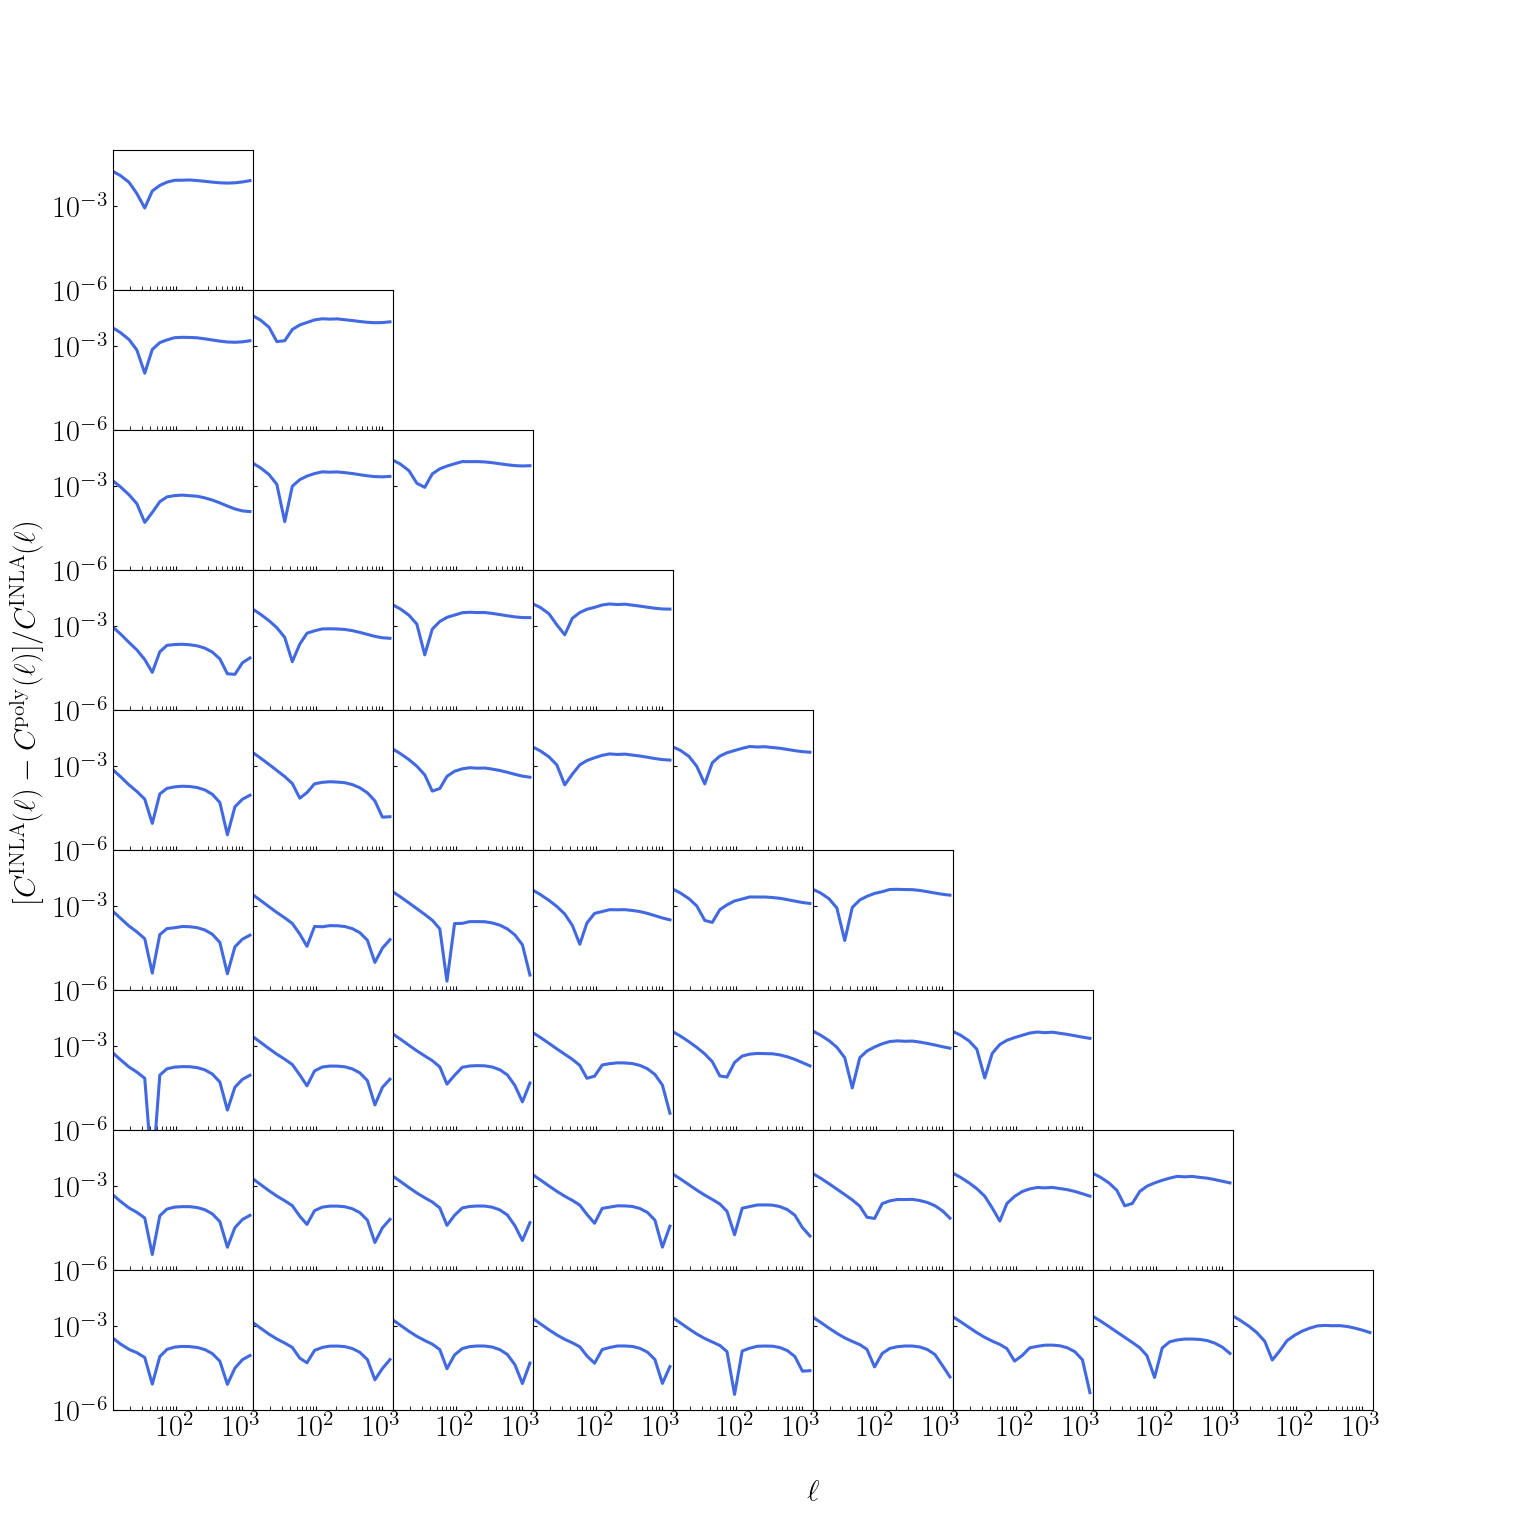

In [9]:
from matplotlib.lines import Line2D
import numpy as np

# Setup
Nbins = 10
ells = Cls['ells']

fig, ax = plt.subplots(Nbins, Nbins, figsize=(14, 14), sharex=True, sharey=True)

for i in range(1, Nbins + 1):
    for j in range(1, Nbins + 1):
        if i <= j:
            ax[i - 1, j - 1].axis("off")
            continue

        key = f'L{j}xL{i}'
        if key not in Cls or key not in Cls_IA:
            ax[i - 1, j - 1].axis("off")
            continue

        Cl_std = Cls[key]
        Cl_IA = Cls_IA[key]
        rel_diff = np.abs(Cl_IA - Cl_std) / Cl_std

        ax[i - 1, j - 1].plot(
            ells,
            rel_diff,
            color="royalblue",
            lw=2.2,
            zorder=2.0
        )
        ax[i - 1, j - 1].tick_params(axis="both", which="both", direction="in", labelsize=22, length=3)
ax[0, 0].set_xscale("log")
ax[0, 0].set_xlim(1 / 3, 1500 * 3)
ax[0, 0].xaxis.get_major_locator().set_params(numticks=99)
ax[0, 0].xaxis.get_minor_locator().set_params(
    numticks=99, subs=np.arange(0.1, 1.0, 0.1)
)
# ax[0, 0].set_yscale(
#     "symlog", linthresh=1e-10, linscale=0.45, subs=np.arange(0.1, 1.0, 0.1)
# )
    
for i in range(Nbins):
    for j in range(Nbins):
        if i > j:
            ax[i, j].set_xscale("log")
            ax[i, j].set_xlim(ells[0], 1500)
            ax[i, j].set_yscale("log")
            ax[i, j].set_ylim(1e-6, 1e-1)

   
fig.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0, wspace=0.0, hspace=0.0)
fig.supxlabel("$\\ell$", y=-0.05, va="top", fontsize=22)
fig.supylabel(r'$[C^{\rm INLA}(\ell)-C^{\rm poly}(\ell)]/C^{\rm INLA}(\ell)$', x=-0.05, ha="right", fontsize=22)


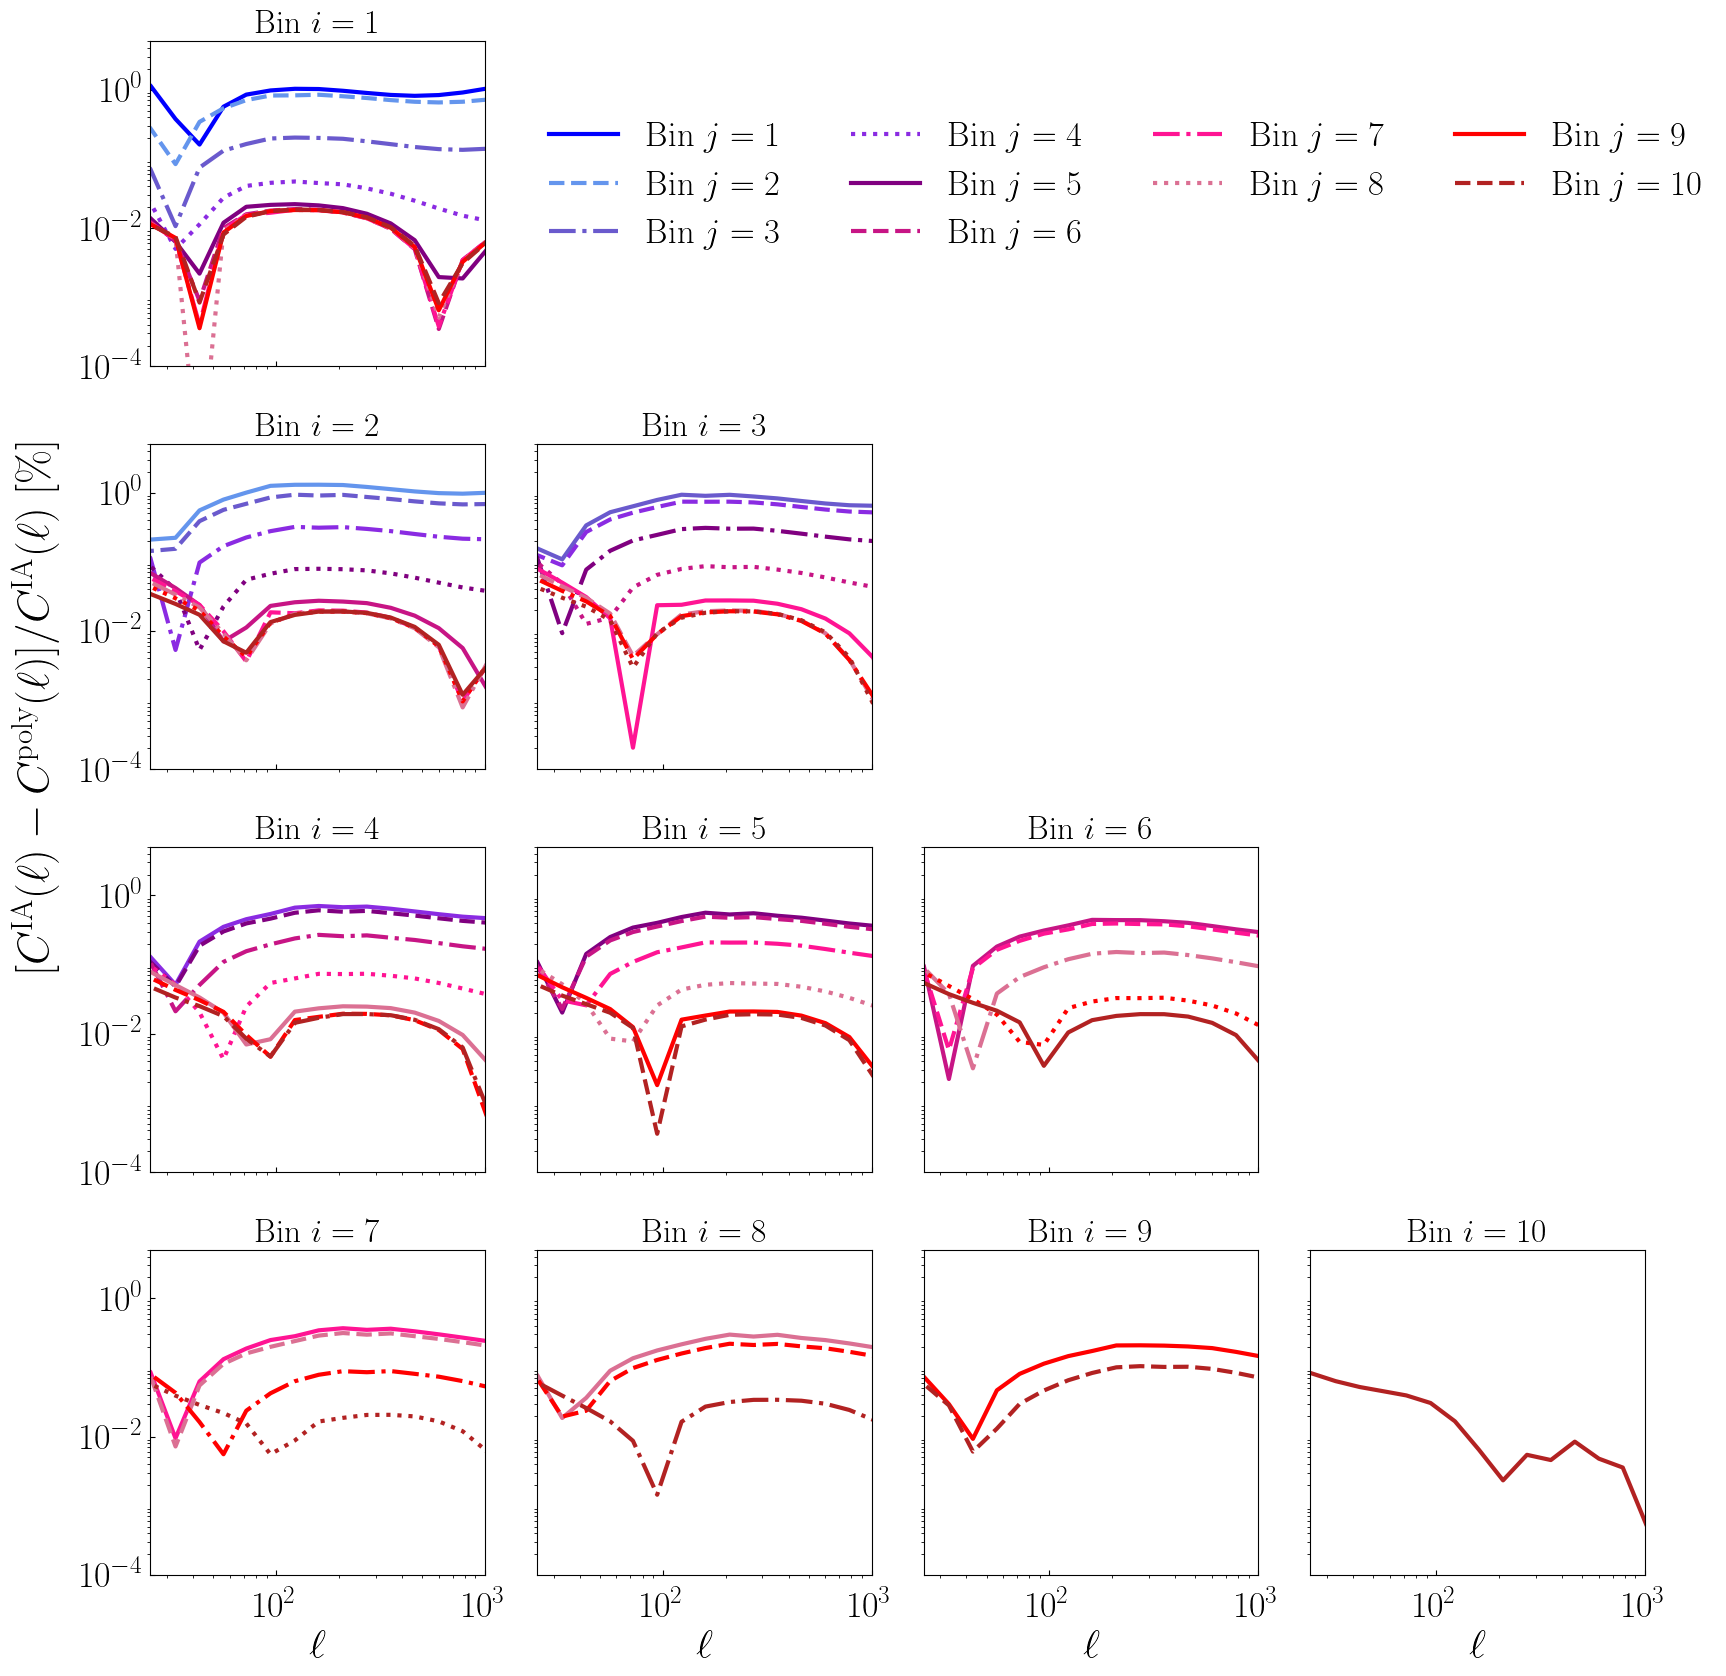

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

# Use your real Cls, Cls_IA, and ells
Nbins = 10
ells = Cls['ells']

# Custom color palette
colors = [
    "blue", "cornflowerblue", "slateblue", "blueviolet", "purple",
    "mediumvioletred", "deeppink", "palevioletred", "red", "firebrick"
]
linestyles = ["-", "--", "-.", ":"]

# Custom triangle layout
triangle_rows = [
    [0],
    [1, 2],
    [3, 4, 5],
    [6, 7, 8, 9]
]

# Create figure and grid
fig = plt.figure(figsize=(20, 18))
gs = GridSpec(
    len(triangle_rows),
    max(len(row) for row in triangle_rows),
    figure=fig
)

# Reference axis for sharing
ax_ref = None

# Keep track of handles/labels for shared legend
legend_handles = []
legend_labels = []

for r, row in enumerate(triangle_rows):
    for c, i in enumerate(row):

        # Create subplot safely
        if ax_ref is None:
            ax = fig.add_subplot(gs[r, c])
            ax_ref = ax
        else:
            ax = fig.add_subplot(
                gs[r, c],
                sharex=ax_ref,
                sharey=ax_ref if c == 0 else None
            )

        for idx, j in enumerate(range(i, Nbins)):
            key = f"L{i+1}xL{j+1}"
            if key not in Cls or key not in Cls_IA:
                continue

            Cl_std = Cls[key]
            Cl_IA = Cls_IA[key]
            rel_diff = np.abs(Cl_IA - Cl_std) / Cl_std * 100

            color = colors[j]
            ls = linestyles[idx % len(linestyles)]
            line, = ax.plot(ells, rel_diff, color=color, lw=3, ls=ls)

            # Store legend entries only once
            if ax is ax_ref:
                legend_handles.append(line)
                legend_labels.append(f"Bin $j={j+1}$")

        ax.set_title(fr"Bin $i = {i+1}$", fontsize=24)
        ax.set_xscale("log")
        ax.set_yscale("log")

        ax.set_xlim(25, 1000)
        ax.set_ylim(1e-4, 5)

        ax.set_yticks([1e-4, 1e-2, 1e0])
        ax.set_yticklabels(
            [ r'$10^{-4}$', r'$10^{-2}$', r'$10^{0}$'],
            fontsize=22
        )

        ax.tick_params(labelsize=26, direction="in")
        ax.tick_params(axis='x', pad=12)


        # Only show y-ticks on first column
        if c != 0:
            ax.set_yticklabels([])
            ax.tick_params(axis='y', left=False)

        # Only show x-ticks on last row
        if r != len(triangle_rows) - 1:
            ax.set_xticklabels([])
            ax.tick_params(axis='x', labelbottom=False)
        else:
            ax.set_xlabel(r'$\ell$', fontsize=30)

# Global Y label
fig.text(
    0.02, 0.58,
    r'$[C^{\rm IA}(\ell) - C^{\rm poly}(\ell)] / C^{\rm IA}(\ell)\;[\%]$',
    va='center', ha='center', rotation='vertical', fontsize=32
)

# Shared legend
fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    loc='upper right',
    bbox_to_anchor=(0.87, 0.92),
    fontsize=25,
    frameon=False,
    ncol=4
)

fig.tight_layout(rect=[0.03, 0.03, 0.85, 0.98])

plt.savefig("./plot/IA_bin_validation.png", dpi=400, bbox_inches="tight")
plt.show()


CAMB vs. MGCAMB

In [34]:
Cls_CAMB  = pd.read_csv(data_path+'_camb_Cls_noiseless.dat',sep='\s+',header=0)


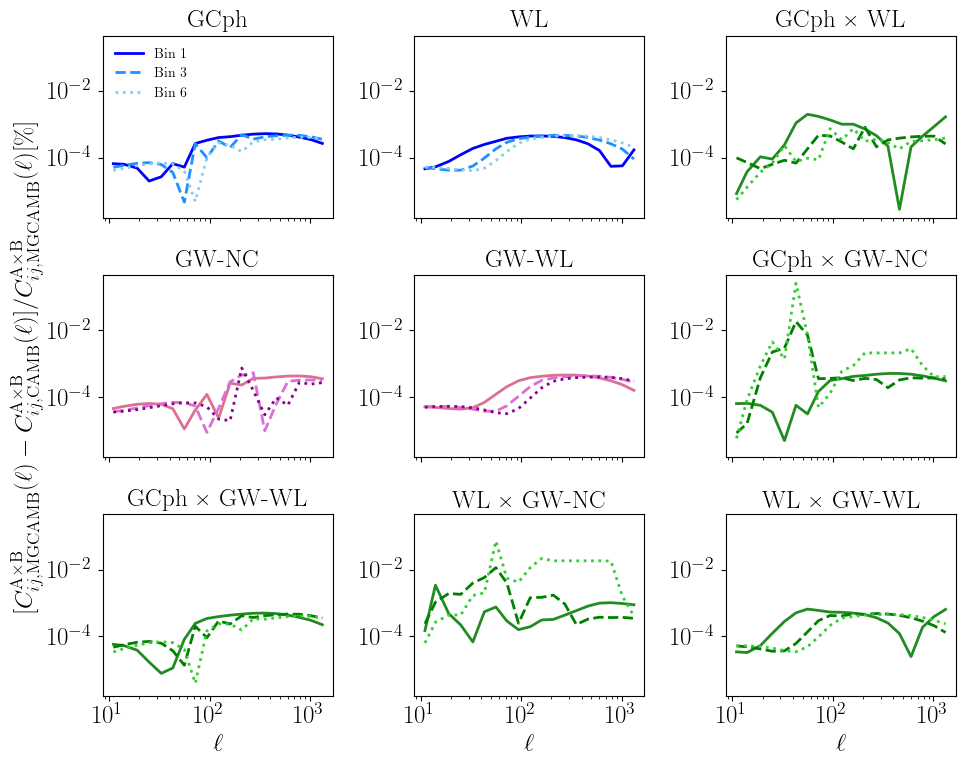

In [36]:

bin_indices = [1, 3, 6]
linestyle = ['-', '--', ':']
gw_palette = ['palevioletred', 'orchid', 'darkmagenta']
cross_palette = ['forestgreen', 'green', 'limegreen']
gal_palette = ['blue', 'dodgerblue', 'skyblue']

subplot_titles = [
    'GCph', 'WL', 'GCph × WL',
    'GW-NC', 'GW-WL', 'GCph × GW-NC',
    'GCph × GW-WL', 'WL × GW-NC', 'WL × GW-WL'
]

title_to_obs = [
    ('G', 'G'), ('L', 'L'), ('G', 'L'),
    ('WC', 'WC'), ('WL', 'WL'), ('G', 'WC'),
    ('G', 'WL'), ('L', 'WC'), ('L', 'WL')
]

ells = Cls['ells']
ell_factor = ells * (ells + 1) / (2 * np.pi)

fig, axs = plt.subplots(3, 3, figsize=(10, 8), sharex=True, sharey=True)

for i, (ax, title, (obs1, obs2)) in enumerate(zip(axs.flat, subplot_titles, title_to_obs)):
    for idx, bi in enumerate(bin_indices):
        key = obs1 + str(bi) + 'x' + obs2 + str(bi)
        if key not in Cls:
            continue

        if obs1 in ['G', 'L'] and obs2 in ['G', 'L'] and obs1 == obs2:
            color = gal_palette[idx]
        elif obs1 in ['WC', 'WL'] and obs2 in ['WC', 'WL'] and obs1 == obs2:
            color = gw_palette[idx]
        else:
            color = cross_palette[idx]


        ax.plot(
            ells,
            np.abs((Cls_CAMB[key]-Cls[key])/Cls[key]),
            color=color,
            linestyle=linestyle[idx],
            linewidth=2
        )

    ax.set_title(title, fontsize=18)
    ax.set_xscale('log')
    ax.set_yscale('log')

    row, col = divmod(i, 3)
    if row == 2:
        ax.set_xlabel(r'$\ell$', fontsize=18)
    else:
        ax.set_xticklabels([])
    if col == 0 and row ==1:
        ax.set_ylabel(r'$[C^{\rm A\times B}_{ij,\rm MGCAMB}(\ell)-C^{\rm A\times B}_{ij\rm, CAMB}(\ell)]/C^{\rm A\times B}_{ij\rm, MGCAMB}(\ell)[\%]$', fontsize = 18)
    ax.tick_params(axis='both', which='both', labelleft=True)


handles = [
    Line2D([0], [0], color=gal_palette[0], lw=2, label='Bin 1', ls = linestyle[0]),
    Line2D([0], [0], color=gal_palette[1], lw=2, label='Bin 3', ls = linestyle[1]),
    Line2D([0], [0], color=gal_palette[2], lw=2, label='Bin 6', ls = linestyle[2]),
]
axs[0, 0].legend(handles=handles, loc='upper left', fontsize=10, frameon = False)


plt.tight_layout()
#plt.savefig("./plot/Cls_CAMB.png", dpi=300, bbox_inches='tight')



In [ ]:
Cls_muSigma  = pd.read_csv('./Validation_data/new_LSS_GW_muSigmaCDM_Cls_noiseless.dat',sep='\s+',header=0)

In [ ]:
from matplotlib.lines import Line2D

bin_indices = [1, 3, 6]
linestyle = ['-', '--', ':']
gw_palette = ['palevioletred', 'orchid', 'darkmagenta']
cross_palette = ['forestgreen', 'green', 'limegreen']
gal_palette = ['blue', 'dodgerblue', 'skyblue']

subplot_titles = [
    'GCph', 'WL', 'GCph × WL',
    'GW-NC', 'GW-WL', 'GCph × GW-NC',
    'GCph × GW-WL', 'WL × GW-NC', 'WL × GW-WL'
]

title_to_obs = [
    ('G', 'G'), ('L', 'L'), ('G', 'L'),
    ('WC', 'WC'), ('WL', 'WL'), ('G', 'WC'),
    ('G', 'WL'), ('L', 'WC'), ('L', 'WL')
]

ells = Cls['ells']

fig, axs = plt.subplots(3, 3, figsize=(10, 8), sharex=True, sharey=True)

for i, (ax, title, (obs1, obs2)) in enumerate(zip(axs.flat, subplot_titles, title_to_obs)):
    for idx, bi in enumerate(bin_indices):
        key = obs1 + str(bi) + 'x' + obs2 + str(bi)
        if key not in Cls:
            continue

        if obs1 in ['G', 'L'] and obs2 in ['G', 'L'] and obs1 == obs2:
            color = gal_palette[idx]
        elif obs1 in ['WC', 'WL'] and obs2 in ['WC', 'WL'] and obs1 == obs2:
            color = gw_palette[idx]
        else:
            color = cross_palette[idx]

        ax.plot(
            ells,
            np.abs((Cls[key]-Cls_muSigma[key])/Cls[key])*100,
            color=color,
            linestyle=linestyle[idx],
            linewidth=2
        )

    ax.set_title(title, fontsize=18)
    ax.set_xscale('log')
    ax.set_yscale('log')

    row, col = divmod(i, 3)
    if row == 2:
        ax.set_xlabel(r'$\ell$', fontsize=18)
    else:
        ax.set_xticklabels([])

    if col == 0 and row ==1:
        ax.set_ylabel(r'$[C^{\rm A \times B}_{ij,\Lambda \rm CDM}(\ell)-C^{\rm A \times B}_{ij\rm, \mu\Sigma \rm CDM}(\ell)]/C^{\rm A\times B}_{ij\rm, \Lambda \rm CDM}(\ell)[\%]$', fontsize = 18)
       
    ax.tick_params(axis='both', which='both', labelleft=True)

handles = [
    Line2D([0], [0], color=gal_palette[0], lw=2, label='Bin 1', ls = linestyle[0]),
    Line2D([0], [0], color=gal_palette[1], lw=2, label='Bin 3', ls = linestyle[1]),
    Line2D([0], [0], color=gal_palette[2], lw=2, label='Bin 6', ls = linestyle[2]),
]
axs[0, 0].legend(handles=handles, loc='upper left', fontsize=10, frameon = False)


plt.tight_layout()
plt.savefig("./plot/Cls_muSigma.png", dpi=300, bbox_inches='tight')

